# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre:** Sergio Alberto Chavez Velazquez

* **matrícula:** A01099484

------------

* #### **En esta actividad puedes apoyarte en uno o varios Modelos de Lenguaje de Gran Tamaño, LLM por sus siglas en inglés (Large Language Model). Indica claramente cuál o cuáles utilizaste.**

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++

La rotacion de Personal o como es conocida en  México la rotacion laboral es un proceso en el cual el colaborador que ocupa un puesto dentro de una organización abandona dicho puesto y es sustituido.
Esto ocurre por 3 Razones puede ser por decicion propia, es decir el colaborador decide irse por propia voluntad (encontro una mejor oportunidad o decide tomar un descanso laborar). La siguiente razon es de manera involuntaria, esto ocurre cuando la empresa es la que decirde separar al colaborador ya sea por restructura o desempeño. La última razón es por movimiento interno, el colaborador pasa a ocupar otro puesto en la organización dejando el puesto actual.

Este fenomeno ha tomado mucha relevancia en las organizacones ya que el tener rotacion de personal especialmente cuando es por decisión del colaborador (razón 1) genera costos, hay fuga de conocimiento y experiencia para la organizacion y puede afectar la productividad general de la empresa.


*** texto original con ideas de Blog de Cegos.

++++++++ Termina la sección de agregar texto. +++++++++++

In [55]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [56]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

ruta_archivo = '/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-HR-Employee-Attrition.csv'

data = pd.read_csv(ruta_archivo)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a) Realiza los análisis descriptivos y/o gráficos que creas adecuados para identificar 4 factores que se deben eliminar desde un inicio.**

**Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



/tmp/ipykernel_2929/3190975387.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unidades.index, y=unidades.values, palette='viridis')


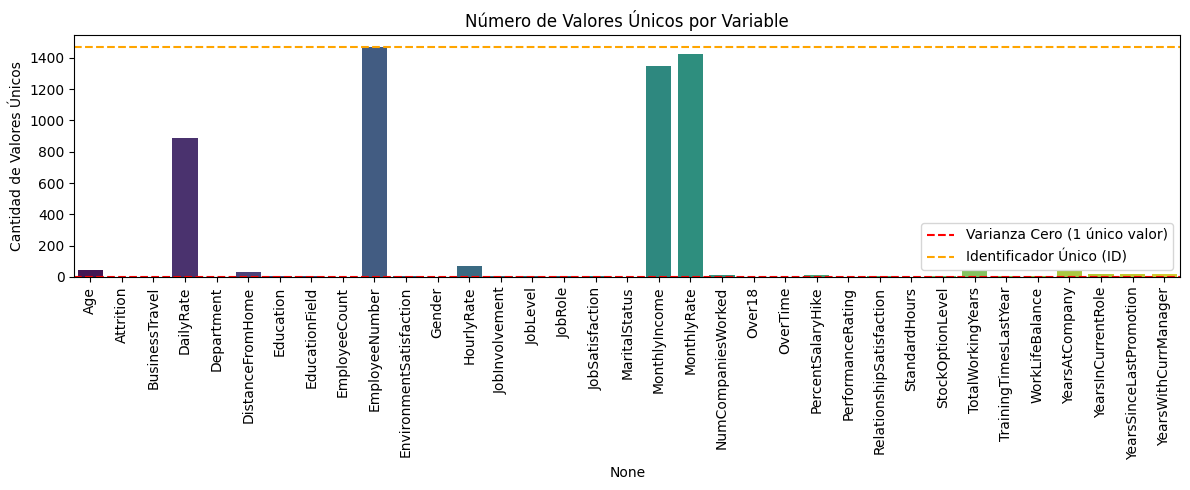

Columnas con un solo valor único (Varianza cero): ['EmployeeCount', 'Over18', 'StandardHours']
Columnas identificadoras (IDs): ['EmployeeNumber']
Lista total a eliminar: ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']

Dimensiones originales: (1470, 35)
Tamaño del nuevo DataFrame: (1470, 31)


In [57]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

unidades = data.nunique()

plt.figure(figsize=(12, 5))
sns.barplot(x=unidades.index, y=unidades.values, palette='viridis')
plt.xticks(rotation=90)
plt.axhline(y=1, color='red', linestyle='--', label='Varianza Cero (1 único valor)')
plt.axhline(y=len(data), color='orange', linestyle='--', label='Identificador Único (ID)')
plt.title('Número de Valores Únicos por Variable')
plt.ylabel('Cantidad de Valores Únicos')
plt.legend()
plt.tight_layout()
plt.show()

columnas_constantes = [col for col in data.columns if data[col].nunique() == 1]
print("Columnas con un solo valor único (Varianza cero):", columnas_constantes)

columnas_id = [col for col in data.columns if data[col].nunique() == len(data)]
print("Columnas identificadoras (IDs):", columnas_id)

factores_a_eliminar = columnas_id + columnas_constantes
print("Lista total a eliminar:", factores_a_eliminar)

df = data.drop(columns=factores_a_eliminar, errors='ignore')


None


# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print(f"\nDimensiones originales: {data.shape}")
print("Tamaño del nuevo DataFrame:", df.shape)

**b) Con base a tu análisis anterior, indica cuáles fueron estas 4 variables y la justificación de por qué se pueden eliminar.**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Las variables que se deben eliminar son 'EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'

Justificacion
EmployeeNumber esta variable es un numero unico para cada empleado que no agrega valor logico al modelo y basicamente es un numero aleatorio para cada empleado el cual no se repite, en caso de dejarlo causa sobreajuste o overfitting

Las otras 3 variables son , 'Over18', 'StandardHours' ya que tienen el mismo numero todos los registros lo cual no aporta ningun valor a la predicción y  'EmployeeCount' es un contador de empleados tampoco aporta valor al modelo de predicción


  ++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes como se indica a continuación y en base a la información dada en la plataforma de Kaggle.**

#### **El número entre corcheas indica el número de variables de dicho tipo y el  número entre paréntesis redondos indica el número de niveles.**

* **Variables numéricas [14]:**

   * NumCompaniesWorked

   * TrainingTimesLastYear

   * Age

   * DailyRate

   * DistanceFromHome

   * HourlyRate

   * MonthlyIncome

   * MonthlyRate

   * PercentSalaryHike

   * TotalWorkingYears

   * YearsAtCompany

   * YearsInCurrentRole

   * YearsSinceLastPromotion

   * YearsWithCurrManager

* **Variables ordinales [9]:**

   * Education (5)

   * EnvironmentSatisfaction (4)

   * JobInvolvement (4)

   * JobLevel (5)

   * JobSatisfaction (4)

   * PerformanceRating (2)

   * RelationshipSatisfaction (4)

   * StockOptionLevel (4)

   * WorkLifeBalance (4)

* **Variables binarias [3]:**

   * Attrition (variable de salida)

   * Gender

   * OverTime

* **Variables nominales [5]:**

   * BusinessTravel (3)

   * Department (3)

   * EducationField (6)

   * JobRole (9)

   * MaritalStatus (3)

**Independientemente de los factores que al final el modelo identifique como los factores más importantes a considerar en este problema de rotación de personal ¿qué preocupaciones éticas o legales podrían generarse, si algunos de estos factores más importantes a considerar para tomar decisiones sobre los empleados fueran la edad (Age), el género (Gender) o el estado civil (Marital Status)?**


++++++++ Inicia la sección de agregar texto: ++++++++++++

Las variables planteadas en la pregunta edad (Age), el género (Gender) o el estado civil (Marital Status) son variables que forman parte de los datos sensibles de cada empleado. si hay alguna de estas variables llegaran a pesar para la deciscion la empresa podria enfrentar acusaciones de discriminacion que puede derivar en una mala reputación o en una demanda legal dependiendo la legislación.

Viendolo desde un ponto de vista mas tecnico esas variables pueden causar que ciertos patrones de sesgos historicos se preserven, incluso cuando las razones de lo analizado no tengan que ver con la variable.

la recomentacion es sacar este tipo de variables que puedan causar un sesgo en el modelo o alguna interpretación de discriminación y falta de ética.



++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

**a) Aunque este problema como está planteado es un problema de clasificación binaria, ¿qué otros enfoques analíticos podrían plantearse y modelarse a partir de este problema? Menciona al menos dos más.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

El planteamiento inicial del problema hace un analisis de Rotacion de personal, que no tienen solo que ver con si un empleado se queda o se va (variable binaria) tambien tiene que ver con cuanto tiempo se queda el colaborador un "Regresion de tiempo de permanencia" , se puede agrupar cuales son los perfiles de empleados en ciertas areas "Clustering" o puede ser un analisis de causas de rotacion tal tez una analisis de causa-efecto.



  ++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [58]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [59]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
le = LabelEncoder()

ytrainT = le.fit_transform(ytrain)
yvalT = le.transform(yval)
ytestT = le.transform(ytest)

print("Mapeo de clases asignado:", dict(zip(le.classes_, range(len(le.classes_)))))
print("\nForma de los arreglos resultantes:")
print("ytrainT:", ytrainT.shape)
print("yvalT:  ", yvalT.shape)
print("ytestT: ", ytestT.shape)

# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', pd.Series(ytrainT).value_counts(normalize=True))


Mapeo de clases asignado: {'No': 0, 'Yes': 1}

Forma de los arreglos resultantes:
ytrainT: (1029,)
yvalT:   (220,)
ytestT:  (221,)
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 0    0.838678
1    0.161322
Name: proportion, dtype: float64


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**


**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**


**d) Con base a la información obtenida y considerando la métrica de la exactitud (accuracy) ¿cuál será el valor del umbral del modelo base o ingenuo (baseline, naive) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**

**e) Indica si el desbalanceo de clases obtenido puede ya considerarse como un problema, y de considerarlo así, qué otra métrica o métricas podrían ser más adecuadas que la exactitud (accuracy).**



++++++++ Inicia la sección de agregar texto: ++++++++++++

b)LabelEncoder está diseñado exclusivamente para codificar la variable respuesta u objetivo (en este caso “Attrition”) en problemas de clasificación.   

c)0 (NO): Representa la clase mayoritaria (empleado retenido). Indica que el colaborador continúa laborando activamente en la empresa.
1 (YES): Representa la clase de interés o minoritaria (empleado que ha sufrido rotación/renuncia). Indica que el colaborador abandonó la organización de forma voluntaria.

d) El umbral de Exactitud (Accuracy) a superar es de (83.9).Cualquier modelo supervisado sofisticado que obtenga un Accuracy 83.9 será inútil u obsoleto, ya que un modelo básico que responda siempre "NO" lograría esa misma exactitud sin ningún aprendizaje real.

e) La exactitud (accuracy) es engañosa aquí: un modelo simplista que prediga que "nadie renuncia" tendría un 84% de exactitud, pero no detectaría a ningún empleado en riesgo.
unas mediciones mas apropiaedas para el tipo de problema serian:
Recall (Sensibilidad): Mide la capacidad de detectar a todos los empleados que realmente van a renunciar (evita falsos negativos).
Precision: Mide la exactitud de las alertas de renuncia (evita gastar recursos en quien no piensa irse).

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gráfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Para la empresa de IBM ¿qué es más costoso? ¿clasificar erróneamente a un empleado que sí renunciará, o por el contrario, generar una falsa alarma?**


Número de variables numéricas/ordinales: 23
Número de variables categóricas nominales: 7
--- DIAGNÓSTICO DE VARIABLES PARA PREPROCESAMIENTO ---
                         Tipo_Dato  Valores_Nulos  Valores_Unicos  \
Age                          int64              0              43   
YearsInCurrentRole           int64              0              19   
YearsAtCompany               int64              0              34   
WorkLifeBalance              int64              0               4   
TrainingTimesLastYear        int64              0               7   
TotalWorkingYears            int64              0              39   
StockOptionLevel             int64              0               4   
RelationshipSatisfaction     int64              0               4   
PerformanceRating            int64              0               2   
PercentSalaryHike            int64              0              15   
NumCompaniesWorked           int64              0              10   
MonthlyRate                 

/tmp/ipykernel_2929/148885465.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


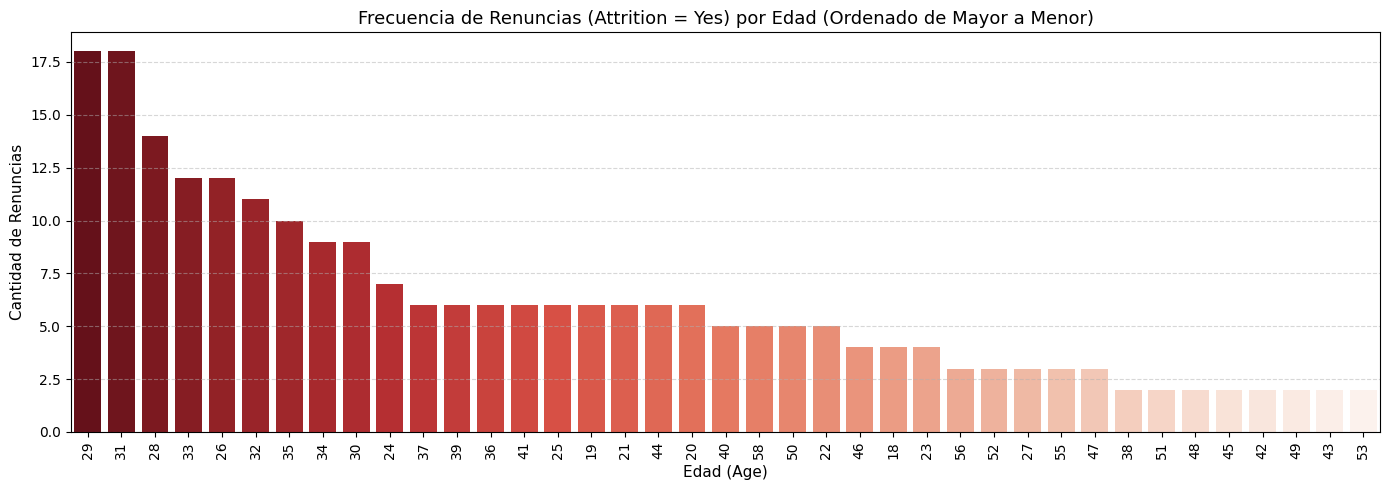

/tmp/ipykernel_2929/148885465.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


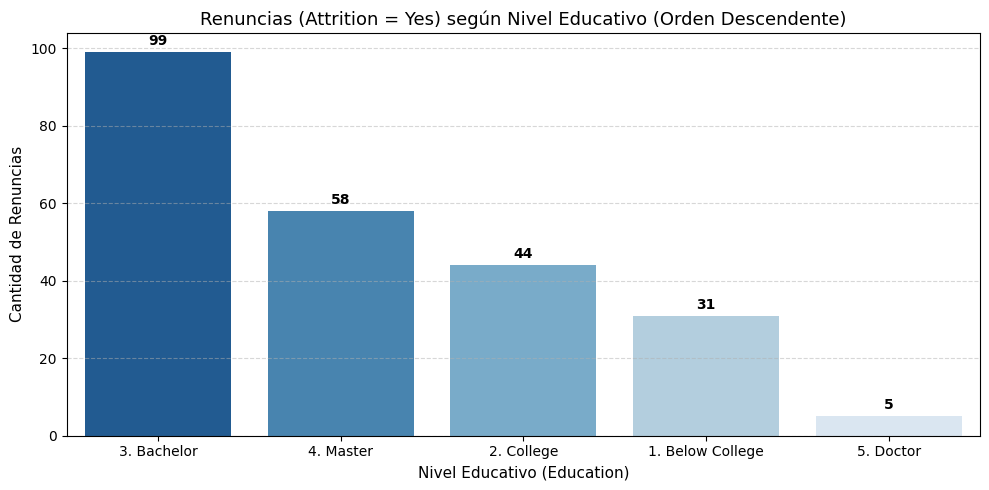

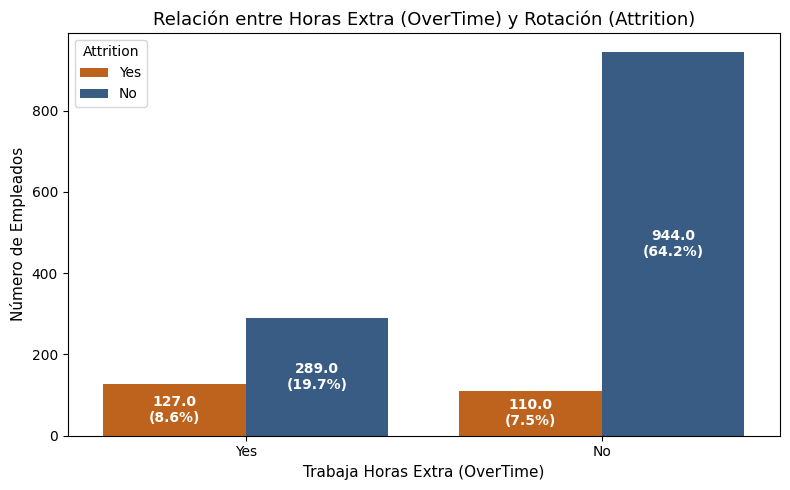

In [60]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

num_cols = Xtrain.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = Xtrain.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Número de variables numéricas/ordinales: {len(num_cols)}")
print(f"Número de variables categóricas nominales: {len(cat_cols)}")

diag_df = pd.DataFrame({
    'Tipo_Dato': Xtrain.dtypes,
    'Valores_Nulos': Xtrain.isnull().sum(),
    'Valores_Unicos': Xtrain.nunique(),
    'Asimetria_Skew': Xtrain.select_dtypes(include=[np.number]).apply(lambda x: x.skew())
})

print("--- DIAGNÓSTICO DE VARIABLES PARA PREPROCESAMIENTO ---")
print(diag_df.sort_values(by='Tipo_Dato'))


# b) Gráfico age-attrition[yes]

df_attrition = df[df['Attrition'] == 'Yes']

age_counts = df_attrition['Age'].value_counts()

plt.figure(figsize=(14, 5))
sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    order=age_counts.index,
    palette='Reds_r'
)

plt.title('Frecuencia de Renuncias (Attrition = Yes) por Edad (Ordenado de Mayor a Menor)', fontsize=13)
plt.xlabel('Edad (Age)', fontsize=11)
plt.ylabel('Cantidad de Renuncias', fontsize=11)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# c) Gráfico education-attrition[yes]

education_map = {
    1: '1. Below College',
    2: '2. College',
    3: '3. Bachelor',
    4: '4. Master',
    5: '5. Doctor'
}

df_attrition_edu = df_attrition.copy()
df_attrition_edu['Education_Label'] = df_attrition_edu['Education'].map(education_map)
edu_counts = df_attrition_edu['Education_Label'].value_counts()


plt.figure(figsize=(10, 5))
sns.barplot(
    x=edu_counts.index,
    y=edu_counts.values,
    order=edu_counts.index,
    palette='Blues_r'
)

for i, value in enumerate(edu_counts.values):
    plt.text(i, value + 1, str(value), ha='center', va='bottom', fontweight='bold')

plt.title('Renuncias (Attrition = Yes) según Nivel Educativo (Orden Descendente)', fontsize=13)
plt.xlabel('Nivel Educativo (Education)', fontsize=11)
plt.ylabel('Cantidad de Renuncias', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# d) [gráfico opcional]

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition',
    palette={'No': '#2b5c8f', 'Yes': '#d95f02'}
)

plt.title('Relación entre Horas Extra (OverTime) y Rotación (Attrition)', fontsize=13)
plt.xlabel('Trabaja Horas Extra (OverTime)', fontsize=11)
plt.ylabel('Número de Empleados', fontsize=11)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height}\n({height/total:.1%})',
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**e) ¿Qué es más costoso, los Falsos Negativos o los Falsos Positivos?**

++++++++ Inicia la sección de agregar texto: ++++++++++++

En el contexto organizacional de IBM,
clasificar erróneamente a un empleado que SÍ renunciará (Falso Negativo) es significativamente MÁS COSTOSO que generar una falsa alarma (Falso Positivo).

*Costo de un Falso Negativo (No detectar a alguien que se va):Costos Directos de Reemplazo: Procesos de reclutamiento, selección, contratación e inducción.
Costos Indirectos: Pérdida de conocimiento técnico acumulado, interrupción en proyectos de clientes clave, fuga de propiedad intelectual y curva de aprendizaje del reemplazo (de 3 a 9 meses para alcanzar la productividad óptima).

*Costo de un Falso Positivo (Falsa alarma - Predecir que se va alguien que se queda):Costo de Intervención: El costo involucrado en aplicar medidas de retención (ej. ofreciendo una sesión de retroalimentación, un plan de desarrollo de carrera, capacitaciones o pequeños bonos).

Conclusión Operativa: La matriz de costos del negocio exige priorizar la métrica Recall (Sensibilidad) sobre la Precision, minimizando a toda costa los Falsos Negativos.



++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo considerado previamente.**



In [61]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# NUMÉRICAS:
numericas_pipeline = Pipeline( None )
numericas_pipeline_nombres = None

# ORDINALES:
catOrd_pipeline = Pipeline( None )
catOrd_pipeline_nombres = None

# BINARIAS:
catBin_pipeline = Pipeline( None )
catBin_pipeline_nombres = None

# NOMINALES:
catNom_pipeline = Pipeline( None )
catNom_pipeline_nombres = None

columnasTransformer = ColumnTransformer( None )

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

# 1. Listas de variables según la clasificación del ejercicio 3
numericas_pipeline_nombres = [
    'NumCompaniesWorked',
    'TrainingTimesLastYear',
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager',
]

catOrd_pipeline_nombres = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'WorkLifeBalance',
]

catBin_pipeline_nombres = ['Gender', 'OverTime']

catNom_pipeline_nombres = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus',
]

# 2. Definición de Pipelines por tipo de transformación
num_pipeline = Pipeline(steps=[('scaler', RobustScaler())])

cat_pipeline = Pipeline(
    steps=[('onehot', OneHotEncoder(drop='first', sparse_output=False))]
)

# 3. Integración en el ColumnTransformer
columnasTransformer = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numericas_pipeline_nombres),
        ('cat_nom', cat_pipeline, catNom_pipeline_nombres),
        ('cat_bin', cat_pipeline, catBin_pipeline_nombres),
        ('ord', 'passthrough', catOrd_pipeline_nombres),
    ],
    verbose_feature_names_out=False,
)

# 4. Ajustar y Transformar ÚNICAMENTE sobre Entrenamiento (Previene Data Leakage)
Xtrain_prep = columnasTransformer.fit_transform(Xtrain)

# 5. Transformar Validación y Prueba usando los parámetros aprendidos en Train
Xval_prep = columnasTransformer.transform(Xval)
Xtest_prep = columnasTransformer.transform(Xtest)

# 6. Verificación de dimensiones
print("Transformación ejecutada exitosamente:")
print('-' * 50)
print(f"Dimensiones Xtrain transformado: {Xtrain_prep.shape}")
print(f"Dimensiones Xval transformado:   {Xval_prep.shape}")
print(f"Dimensiones Xtest transformado:  {Xtest_prep.shape}")

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

Transformación ejecutada exitosamente:
--------------------------------------------------
Dimensiones Xtrain transformado: (1029, 44)
Dimensiones Xval transformado:   (220, 44)
Dimensiones Xtest transformado:  (221, 44)


* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [62]:

Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrain, yval], axis=0)

print("Dimensión de Xtv y ytv (Pandas DataFrames/Series):")
print(Xtv.shape)
print(ytv.shape)

Dimensión de Xtv y ytv (Pandas DataFrames/Series):
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados con respecto a la métrica de la exactitud (accuracy).**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados, independientemente de la métrica a considerar. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera los problemas y obtener mejores resultados.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold" utilizada en este ejercicio, puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.883 (0.019)
>> LASSO 0.889 (0.018)
>> RIDGE 0.889 (0.016)
>> EN 0.888 (0.018)
>> KNN 0.850 (0.005)


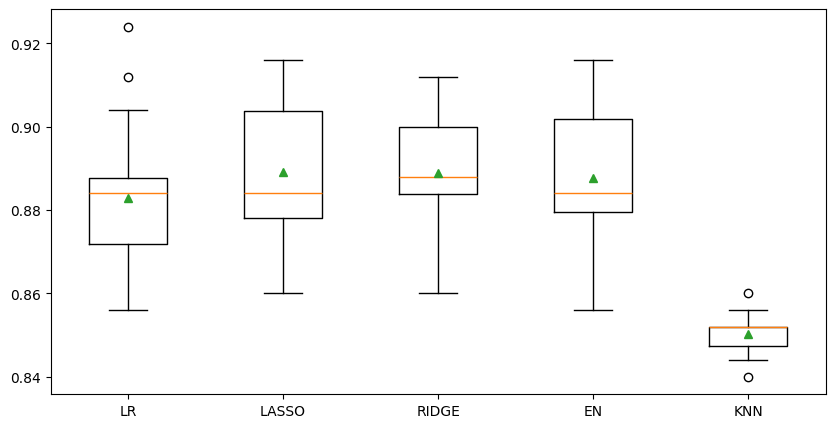

In [63]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás modificarlo.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
def mis_modelos():
    modelos, nombres = list(), list()

    # 1. LR - Regresión Logística sin regularización
    modelos.append(
        LogisticRegression(
            penalty=None, solver='lbfgs', max_iter=1000, random_state=1
        )
    )
    nombres.append('LR')

    # 2. LASSO - Regresión Logística con regularización L1
    modelos.append(
        LogisticRegression(
            penalty='l1', solver='saga', C=1.0, max_iter=2000, random_state=1
        )
    )
    nombres.append('LASSO')

    # 3. RIDGE - Regresión Logística con regularización L2
    modelos.append(
        LogisticRegression(
            penalty='l2', solver='lbfgs', C=1.0, max_iter=1000, random_state=1
        )
    )
    nombres.append('RIDGE')

    # 4. EN - Regresión Logística con regularización ElasticNet (L1 + L2)
    modelos.append(
        LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=0.5,
            C=1.0,
            max_iter=2000,
            random_state=1,
        )
    )
    nombres.append('EN')

    # 5. KNN - K-Vecinos más cercanos
    modelos.append(
        KNeighborsClassifier(
            n_neighbors=7, weights='distance', metric='minkowski', p=2
        )
    )
    nombres.append('KNN')

    return modelos, nombres

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay obviamente varias maneras de llevar a cabo el entrenamiento,
# pero por el momento supongamos que lo hacemos de la manera siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados con la exactitud (accuracy).


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo. ¿Alguno quedó subentrenado y ya no se pudo mejorar su desempeño?**

++++++++ Inicia la sección de agregar texto: ++++++++++++
Tomando en cuenta el parametro de beanckmark que traemos 83.3 %  (la proporción de la clase mayoritaria Attrition = NO). podemos observar que ningun modelo quedo subentrenado.
los modelos LASSO, RIDGE y EN  comparten un promedio similar de desempeño sin embargo si tenemos que elegir unos el ganador serua el modelo Rigde ya que tiene la misma media pero tiene una desviacion estandar mas pequeña. seguido de los modelos Lasso y EN

el caso de el modelo KNN si bien tiene un desempeño superior (85% vs 83.3) está sufriendo la maldición de la dimensionalidad. Incluso tras la reducción por One-Hot Encoding, el número de dimensiones incrementa la distancia euclidiana promedio entre puntos, perdiendo efectividad en comparación con los modelos lineales. En terminos practicos no esta subentrenado pero es el el modelo con peor desempeño.


++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [64]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


# 1. Definición del modelo base y rejilla de hiperparámetros
Xtv_prep = np.concatenate([Xtrain_prep, Xval_prep], axis=0)
ytvT = np.concatenate([ytrainT, yvalT], axis=0)

modelo_ridge = LogisticRegression(penalty='l2', random_state=1, max_iter=2000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'solver': ['lbfgs', 'saga', 'liblinear']
}

# 2. Esquema de Validación Cruzada
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

# 3. Asignación directa a 'resultado_malla' como el objeto GridSearchCV
resultado_malla = GridSearchCV(
    estimator=modelo_ridge,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    return_train_score=True  # Permite extraer las métricas de Train
)

# Se entrena sobre el conjunto combinado Train + Val
resultado_malla.fit(Xtv_prep, ytvT)

# 4. Extracción de índices y métricas del mejor modelo
best_idx = resultado_malla.best_index_

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100*resultado_malla.cv_results_['std_test_score'].mean()))


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.890580 usando los hiperparámetros {'C': 0.5, 'solver': 'lbfgs'}
Promedios Train mean(std): 88.95% (0.3955%)
Promedios Val mean(std): 87.54% (1.3891%)


NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.
Train tiene 88.95 Validation tiene un promedio de 87.5 por lo que la diferencia no supera el 3%

# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [65]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++
from sklearn.metrics import accuracy_score, classification_report

# 1. Realizar predicciones sobre el conjunto de prueba (Test) preprocesado
ypred_test = resultado_malla.predict(Xtest_prep)

# 2. Generar y desplegar el reporte de clasificación completo
print("==================================================================")
print("       DESEMPEÑO FINAL DEL MEJOR MODELO (CONJUNTO DE TEST)       ")
print("==================================================================")
print(
    classification_report(
        ytestT,
        ypred_test,
        target_names=['No Attrition (0)', 'Attrition (1)'],
        digits=4,
    )
)

# 3. Cálculo del Accuracy global en Test
acc_test = accuracy_score(ytestT, ypred_test)
print(f"Accuracy en Test: {acc_test * 100:.2f}%")
print("==================================================================")

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


       DESEMPEÑO FINAL DEL MEJOR MODELO (CONJUNTO DE TEST)       
                  precision    recall  f1-score   support

No Attrition (0)     0.8788    0.9405    0.9086       185
   Attrition (1)     0.5217    0.3333    0.4068        36

        accuracy                         0.8416       221
       macro avg     0.7003    0.6369    0.6577       221
    weighted avg     0.8206    0.8416    0.8269       221

Accuracy en Test: 84.16%


Matriz de Confusión (Numérica):
[[174  11]
 [ 24  12]]


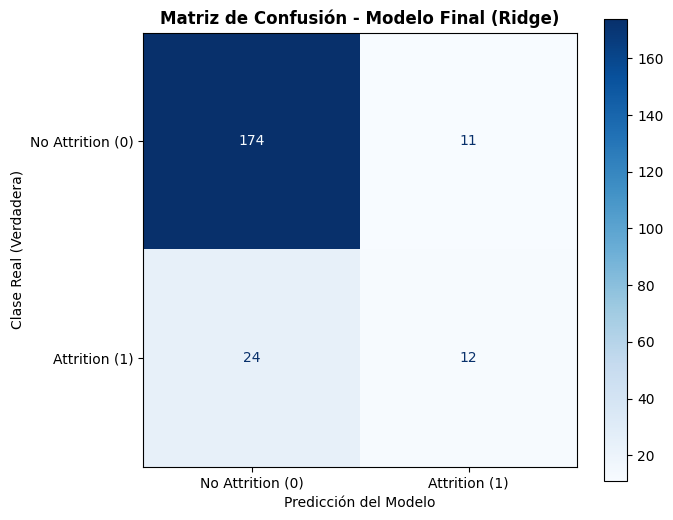

In [66]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# 1. Calcular la matriz de confusión sobre el conjunto de prueba (Test)
cm = confusion_matrix(ytestT, ypred_test)

print("Matriz de Confusión (Numérica):")
print(cm)

# 2. Desplegar la matriz de confusión de forma gráfica
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Attrition (0)', 'Attrition (1)']
)

disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(
    "Matriz de Confusión - Modelo Final (Ridge)", fontsize=12, fontweight='bold'
)
plt.xlabel("Predicción del Modelo", fontsize=10)
plt.ylabel("Clase Real (Verdadera)", fontsize=10)
plt.grid(False)
plt.show()


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++


* **VP:** [Arriba-Derecha] Empleados que NO renunciaron y el modelo clasificó correctamente como No Attrition. 174 casos

* **VN:** [Abajo-Derecha] Empleados que SÍ renunciaron y el modelo identificó con éxito.12 casos

* **FP:** [Arriba-Derecha] Empleados que NO renunciaron, pero el modelo los clasificó erróneamente como Attrition (Falsa alarma). 11 casos

* **FN:** [Abajo-Izquierda] Empleados que SÍ renunciaron, pero el modelo los predijo como No Attrition (Error más costoso para el área de RRHH como lo vimos en los ejercicios anteriores). 24 casos


#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

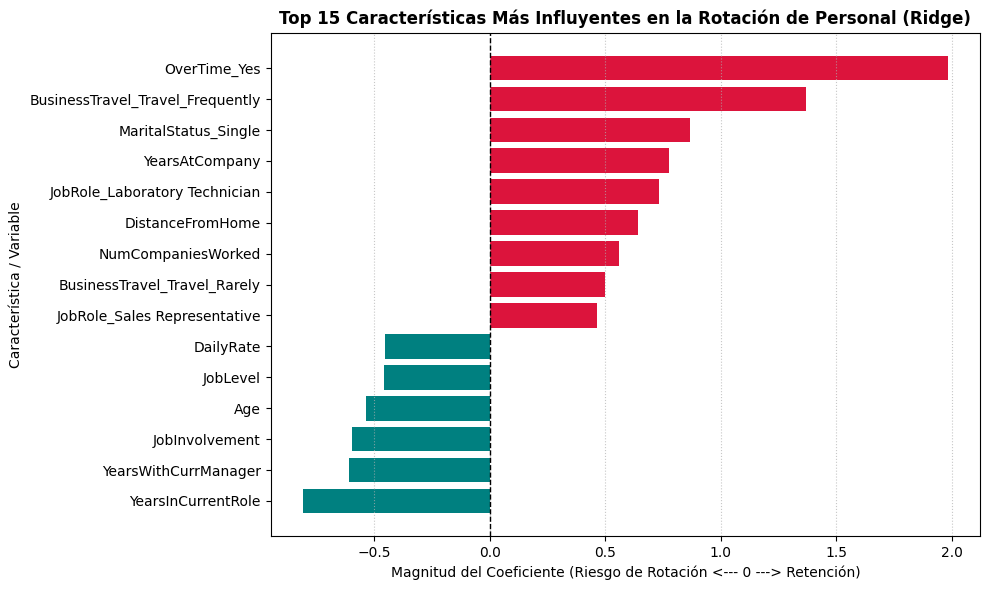

Top 10 Variables con Mayor Impacto:
                  Caracteristica  Coeficiente
                    OverTime_Yes     1.982092
BusinessTravel_Travel_Frequently     1.366665
            MaritalStatus_Single     0.865251
              YearsInCurrentRole    -0.809710
                  YearsAtCompany     0.776131
   JobRole_Laboratory Technician     0.732911
                DistanceFromHome     0.640183
            YearsWithCurrManager    -0.611715
                  JobInvolvement    -0.595068
              NumCompaniesWorked     0.557450


In [67]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


feature_names = columnasTransformer.get_feature_names_out()

coeficientes = resultado_malla.best_estimator_.coef_[0]

df_importance = pd.DataFrame({
    'Caracteristica': feature_names,
    'Coeficiente': coeficientes,
    'Impacto_Absoluto': np.abs(coeficientes)
}).sort_values(by='Impacto_Absoluto', ascending=False)


top_15 = df_importance.head(15).sort_values(by='Coeficiente', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['crimson' if c > 0 else 'teal' for c in top_15['Coeficiente']]
plt.barh(top_15['Caracteristica'], top_15['Coeficiente'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Top 15 Características Más Influyentes en la Rotación de Personal (Ridge)', fontsize=12, fontweight='bold')
plt.xlabel('Magnitud del Coeficiente (Riesgo de Rotación <--- 0 ---> Retención)', fontsize=10)
plt.ylabel('Característica / Variable', fontsize=10)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 Variables con Mayor Impacto:")
print(df_importance[['Caracteristica', 'Coeficiente']].head(10).to_string(index=False))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++
**Contexto**
Para analizar cuales son los factures mas importantes dentro de la rotaciuon de presonal tenemos 2 vertientes, Factores que promueven la rotacion, es decir que hacen que las personas quieran irse y por otro lado tenemos los factores que promueven las retencion. a continuacion se presentan los mas relevantes de ambos casos.

**Factores que incrementan la probabilidad de rotación (Coeficientes Positivos — Barras Rojas):**

Horas Extra (OverTime_Yes): Es, por mucho, el predactor #1 de renuncia. Trabajar tiempo extra constante genera sobrecarga laboral (burnout), siendo la causa principal de fuga de talento.

Viajes Frecuentes de Negocio (BusinessTravel_Travel_Frequently): El desgaste físico y la interrupción del equilibrio personal por viajes constantes incrementan significativamente el riesgo de salida.

Estado Civil Soltero/a (MaritalStatus_Single): Los empleados solteros suelen tener menor atadura familiar directa o responsabilidades financieras compartidas, lo que les da mayor movilidad laboral.

Puestos Específicos (JobRole_Laboratory Technician  y JobRole_Sales Representative): Estas posiciones operativas/comerciales muestran un riesgo inherente mayor de rotación, posiblemente por alta presión o salarios de entrada.

Distancia al Trabajo y Trayectoria (DistanceFromHome y NumCompaniesWorked): Traslados largos desgastaron al personal al igual que un historial de haber cambiado frecuentemente de empresa en el pasado.

**Factores que promueven la retención (Coeficientes Negativos — Barras Verdes)**:

Satisfacción con el Entorno (EnvironmentSatisfaction / JobSatisfaction): Un ambiente laboral favorable y la alineación con el puesto reducen sensiblemente el riesgo de renuncia.

Ingreso Mensual (MonthlyIncome): Una compensación competitiva actúa como un factor higiénico fundamental para la permanencia.

Años en la Compañía (YearsAtCompany / YearsWithCurrManager): La antigüedad y la estabilidad en la relación con el líder directo generan sentido de pertenencia y compromiso institucional.

**Reflexion o recomendacion **

Se puede ver como los factores mas relevantes no son solo economicos para evitar la rotacion de personal. En terminos generales hay muchos factores de balance de vida y carrera que influyen en la rotacion como viajes frecuentes, Horas extra y grandes distancias que hacen que las presonas pasen menos tiempo con su familia.

Caso contrario la contancia y planes definidios de carrera hacen que las personas decidan permanecer. tambien con su liderago actual

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quiénes de los colaboradores de la empresa estarán abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) Con base a los resultados de la matriz de confusión, ¿qué tipo de error (FN o FP) está considerando como más costoso el modelo? En particular, ¿coincide con la respuesta que diste en el Ejercicio 6e?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, supongamos que vas a comunicarle tus resultados a los directivos de la empresa o al personal del área de Recursos Humanos.**

* **d) ¿En cuáles ejercicios anteriores consideras que el (o los) modelo de lenguaje de gran tamaño LLM utilizado fue de mayor ayuda? ¿Por qué?**

* **e) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


* a) Analizando el modelo las variables mas significativas que predicen la rotacion no tieene que ver con variables que podrian considerares sensibles.
por otra parte el usar esta informacion como motivo para termionar relaciones laborales o no contratar con esas caracteristicas si podria meter a la empresa en problas legales o de mala reputacion. lo que refuerza la recomendacion de sacarlas de los modelos.
RRHH junto con el managment de la empresa. se debe de centrar en factores como clima laborar, equilibrio de vida y carrera y un pathway definido para las personas y con eso lograra los objetivos de rotacion.

* b) definitivamente conicide y refuerza que la rotacion cuando es sin tener tiempo de buscar remplazo es la mas costosa para la empresa. no nada mas por el costo de reclutar sino por la disminucion de productividad fuga de conocimiento, entre otros factores.

* c) El análisis predictivo revela que el principal factor de riesgo en la rotación de personal es el desgaste asociado a las horas extra de trabajo , complementado por la alta frecuencia de viajes de negocio y los largos trayectos al centro laboral; lo cual se puede resumir como falta de balance de trabajo vs la vida personal de los colaboradores;
mientras que la estabilidad en el puesto actual, una sólida relación con el líder directo y un mayor nivel de compromiso e ingreso actúan como las principales anclas de retención. por lo que es primordial efoncarse en liderazgo plan de vida y carrera y balance de vida.

* d) definitivamente en el ejercicio 9 donde no hay referencias escritas y te piden un metodo para sacar el resultado. y tambien en los ejecricios de grafica me ayudo bastante en depurar los errores y generar codigoq ue me hacia falta para mostrar correctamente lo que se pedia en los ejercicios

* e) Este analisis me gusto mucho tanto en la parte tecnica, es decir si habia ejercicios que significaron un desafio a nivel tecnico para desarrollar pero tambien me gusto mucho el fondo del caso. donde analizas rotacion de personal, clima laboral y descubres que factores son los que mas impactan.


**Referencias**

Cegos. (s. f.). Rotación de personal: qué es, causas, consecuencias y cómo reducirla. Cegos España. https://www.cegos.es/noticias/rotacion-de-personal-que-es-causas-consecuencias-y-como-reducirla

Google. (2026). Gemini (Versión de septiembre de 2026) [Modelo de lenguaje de inteligencia artificial]. https://gemini.google.com Utilizado como apoyo para organizar ideas,depuración de código y verificación de errores . El contenido final fue revisado, adaptado y validado por el autor.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de Rotación de Personal de la Semana 3** <<